In [1]:
from mscg import *
from mscg.cli import cgmap

import matplotlib.pyplot as plt

AA_traj = Trajectory('subset.trr', fmt='trr')
AA_traj.read_frame()
AA_traj.x.shape

# map atomistic traj to CG traj
cgmap.main(map='map_dna_subset.yaml', traj='subset.trr', out='CG.lammpstrj')

CG_traj = Trajectory('CG.lammpstrj', fmt='lammpstrj')
CG_traj.read_frame()
CG_traj.x.shape

(10, 3)

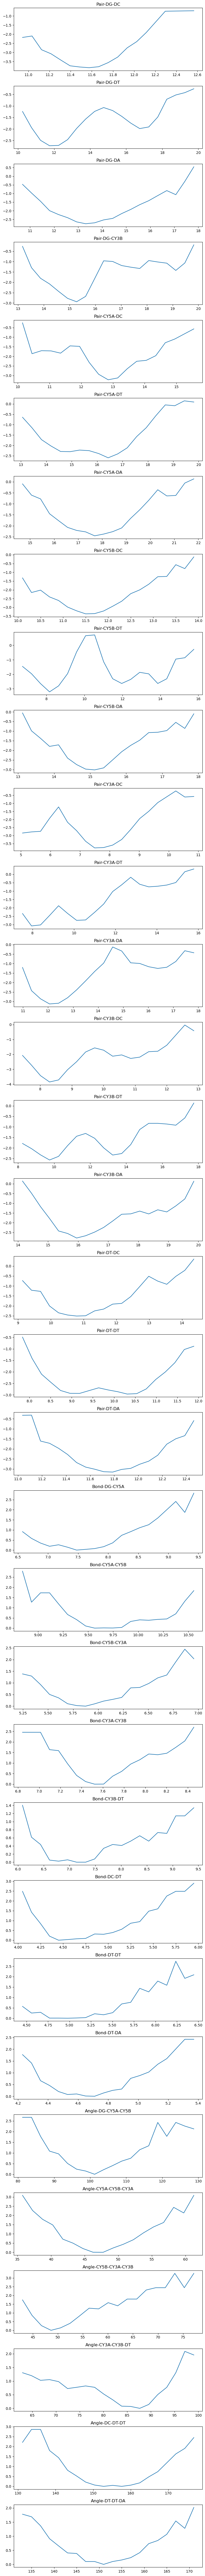

In [5]:
from mscg.cli import cgib

result = cgib.main(
    top     = "0nt_subset_top",
    traj    = "CG.lammpstrj",
    names   = "DG,DT,DA,DC,CY5A,CY5B,CY3A,CY3B",
    cut     = 30.0,
    pair    = [
        'DG,DC,min=10.9,max=12.7,bins=20',
        'DG,DT,min=10,max=20,bins=20',
        'DG,DA,min=10.5,max=18,bins=20',
        'DG,CY3B,min=13,max=20,bins=20',
        'CY5A,DC,min=10,max=16,bins=20',
        'CY5A,DT,min=12.5,max=20,bins=20',
        'CY5A,DA,min=14.5,max=22,bins=20',
        'CY5B,DC,min=10,max=14,bins=20',
        'CY5B,DT,min=6.5,max=16,bins=20',
        'CY5B,DA,min=13,max=18,bins=20',
        'CY3A,DC,min=4.9,max=11,bins=20',
        'CY3A,DT,min=7.3,max=16,bins=20',
        'CY3A,DA,min=10.8,max=18,bins=20',
        'CY3B,DC,min=7.3,max=13,bins=20',
        'CY3B,DT,min=8,max=18,bins=20',
        'CY3B,DA,min=14,max=20,bins=20',
        'DT,DC,min=9,max=14.5,bins=20',
        'DT,DT,min=7.5,max=12,bins=20',
        'DT,DA,min=11,max=12.5,bins=20'
    ],
    bond    = [
        'DG,CY5A,min=6.5,max=9.5,bins=20',
        'CY5A,CY5B,min=8.8,max=10.6,bins=20',
        'CY5B,CY3A,min=5.2,max=7.0,bins=20',
        'CY3A,CY3B,min=6.8,max=8.5,bins=20',
        'CY3B,DT,min=6.0,max=9.5,bins=20',
        'DC,DT,min=4.0,max=6.0,bins=20',
        'DT,DT,min=4.4,max=6.5,bins=20',
        'DT,DA,min=4.2,max=5.4,bins=20'
    ],
    angle    = [
        'DG,CY5A,CY5B,min=80,max=130,bins=20',
        'CY5A,CY5B,CY3A,min=35,max=65,bins=20',
        'CY5B,CY3A,CY3B,min=42,max=80,bins=20',
        'CY3A,CY3B,DT,min=62,max=100,bins=20',
        'DC,DT,DT,min=130,max=178,bins=20',
        'DT,DT,DA,min=132,max=172,bins=20'
    ],
    save    = "return"
)

fig, axes = plt.subplots(len(result), 1, figsize=(8, 3 * len(result)))
for ax, r in zip(axes, result):
    hist = r['data']
    ax.plot(hist[:, 0], hist[:, 2])
    ax.set_title(r.get('name', ''))
plt.tight_layout()
plt.show()

In [ ]:
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter
import numpy as np
import os

fig, axes = plt.subplots(len(result), 1, figsize=(8, 3 * len(result)))

splines = {}

for ax, r in zip(axes, result):
    hist = r['data']
    x = hist[:, 0]
    pmf = hist[:, 2]
    name = r.get('name', '')

    mask = np.isfinite(pmf)
    x_clean, pmf_clean = x[mask], pmf[mask]

    pmf_sg = savgol_filter(pmf_clean, window_length=3, polyorder=2)
    spl = UnivariateSpline(x_clean, pmf_sg, k=3, s=0)

    x_fine = np.linspace(x_clean[0], x_clean[-1], 300)
    ax.plot(x_clean, pmf_clean, 'o-', alpha=0.5, label='BI raw')
    ax.plot(x_fine, spl(x_fine), '-', lw=2, label=f'Spline ({len(spl.get_knots())} knots)')
    ax.set_title(name)
    ax.set_xlabel('r')
    ax.set_ylabel('PMF')
    ax.legend(fontsize=8)

    splines[name] = (spl, x_clean)

plt.tight_layout()
plt.show()

os.makedirs("splines", exist_ok=True)
with open("splines/model.txt", "w") as f:
    for name, (spl, x_clean) in splines.items():
        x_min = round(float(x_clean[0]), 6)
        x_max = round(float(x_clean[-1]), 6)
        n_intervals = 20

        x_uniform = np.linspace(x_min, x_max, n_intervals + 1)
        pmf_uniform = spl(x_uniform)
        spl_uniform = UnivariateSpline(x_uniform, pmf_uniform, k=3, s=0)
        t, c, k = spl_uniform._eval_args
        c_trimmed = c[:len(t) - k - 1]

        interaction_type, safe_name = name.split("-", 1)

        coeff_str = " ".join(f"{v:.6g}" for v in c_trimmed)
        f.write(f"{interaction_type}_{safe_name} {x_min} {x_max} {x_min} L2 {coeff_str}\n")

print("Saved: splines/model.txt")

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import make_lsq_spline

PAIR_RES  = 0.5
BOND_RES  = 0.5
ANGLE_RES = 3.0
ORDER     = 4
SIGMA     = 1.5
TABLE_DR  = 0.005   # fine spacing for LAMMPS table output
EXTRAP    = "L2"     # extrapolation scheme (matching tutorial)

interactions = [
    # (name, itype, xmin, xmax, resolution, order, result_index)
    # ---------- PAIRS (19) ----------
    ("Pair_DG-DC",       "pair",  10.5,   12.5,  PAIR_RES, 4,  0),  # 4
    ("Pair_DG-DT",       "pair",  10.0,   20.0,  PAIR_RES, 4,  1),  # 20
    ("Pair_DG-DA",       "pair",  10.5,   18.0,  PAIR_RES, 4,  2),  # 15
    ("Pair_DG-CY3B",     "pair",  13.0,   20.0,  PAIR_RES, 4,  3),  # 14
    ("Pair_CY5A-DC",     "pair",  10.0,   16.0,  PAIR_RES, 4,  4),  # 12
    ("Pair_CY5A-DT",     "pair",  12.5,   20.0,  PAIR_RES, 4,  5),  # 15
    ("Pair_CY5A-DA",     "pair",  14.5,   22.0,  PAIR_RES, 4,  6),  # 15
    ("Pair_CY5B-DC",     "pair",  10.0,   14.0,  PAIR_RES, 4,  7),  # 8
    ("Pair_CY5B-DT",     "pair",  6.5,    16.0,  PAIR_RES, 4,  8),  # 19
    ("Pair_CY5B-DA",     "pair",  13.0,   18.0,  PAIR_RES, 4,  9),  # 10
    ("Pair_CY3A-DC",     "pair",  4.5,    11.0,  PAIR_RES, 4, 10),  # 13
    ("Pair_CY3A-DT",     "pair",  7.0,    16.0,  PAIR_RES, 4, 11),  # 18
    ("Pair_CY3A-DA",     "pair",  10.5,   18.0,  PAIR_RES, 4, 12),  # 15
    ("Pair_CY3B-DC",     "pair",  7.0,    13.0,  PAIR_RES, 4, 13),  # 12
    ("Pair_CY3B-DT",     "pair",  8.0,    18.0,  PAIR_RES, 4, 14),  # 20
    ("Pair_CY3B-DA",     "pair",  14.0,   20.0,  PAIR_RES, 4, 15),  # 12
    ("Pair_DT-DC",       "pair",  9.0,    14.5,  PAIR_RES, 4, 16),  # 11
    ("Pair_DT-DT",       "pair",  7.5,    12.0,  PAIR_RES, 4, 17),  # 9
    ("Pair_DT-DA",       "pair",  11.0,   12.5,  PAIR_RES, 4, 18),  # 3

    # BONDS — resolution = 0.5
    ("Bond_DG-CY5A",     "bond",  6.5,    9.5,   BOND_RES, 4, 19),  # 6
    ("Bond_CY5A-CY5B",   "bond",  8.5,    10.5,  BOND_RES, 4, 20),  # 4
    ("Bond_CY5B-CY3A",   "bond",  5.0,    7.0,   BOND_RES, 4, 21),  # 4
    ("Bond_CY3A-CY3B",   "bond",  6.5,    8.5,   BOND_RES, 4, 22),  # 4
    ("Bond_CY3B-DT",     "bond",  6.0,    9.5,   BOND_RES, 4, 23),  # 7
    ("Bond_DC-DT",       "bond",  4.0,    6.0,   BOND_RES, 4, 24),  # 4
    ("Bond_DT-DT",       "bond",  4.0,    6.5,   BOND_RES, 4, 25),  # 5
    ("Bond_DT-DA",       "bond",  4.0,    5.5,   BOND_RES, 4, 26),  # 3

    # ANGLES — resolution = 3.0
    ("Angle_DG-CY5A-CY5B",     "angle", 79,  130, ANGLE_RES, 4, 27),  # 17
    ("Angle_CY5A-CY5B-CY3A",   "angle", 35,   65, ANGLE_RES, 4, 28),  # 10
    ("Angle_CY5B-CY3A-CY3B",   "angle", 41,   80, ANGLE_RES, 4, 29),  # 13
    ("Angle_CY3A-CY3B-DT",     "angle", 61,  100, ANGLE_RES, 4, 30),  # 13
    ("Angle_DC-DT-DT",         "angle", 130, 178, ANGLE_RES, 4, 31),  # 16
    ("Angle_DT-DT-DA",         "angle", 132, 174, ANGLE_RES, 4, 32),  # 14
]